# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [3]:
import numpy as np
from PIL import Image
from skimage import data
import matplotlib.pyplot as plt

%matplotlib inline

Image size: (256, 256)


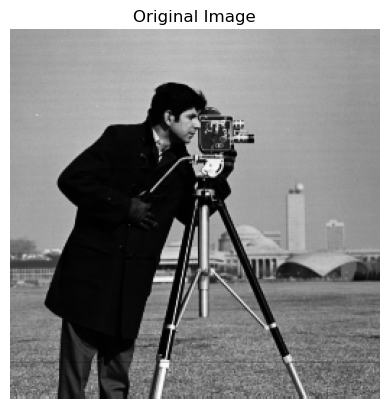

In [4]:
image = Image.open(r"C:\Users\hello\Music\cameraman.png")

print("Image size:", image.size)

plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()


### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [5]:
# Get the size of the image
width, height = image.size

print("Original size:", image.size)
# scaling factors
cx = 2
cy = 2

Original size: (256, 256)


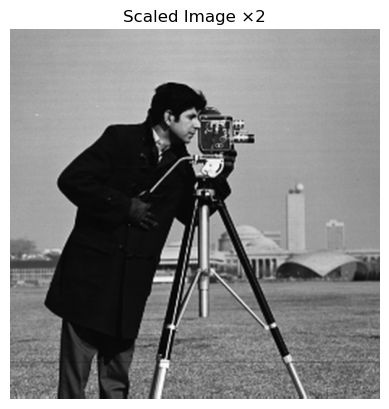

Original size: (256, 256)
Scaled size: (512, 512)


In [6]:
# ── 1. Increase size (scale ×2) ────────────────────
# Resize the image using PIL's built-in method
scaled_image = image.resize(
    (width * 2, height * 2),
    Image.Resampling.LANCZOS
)


plt.imshow(scaled_image, cmap="gray")
plt.title("Scaled Image ×2")
plt.axis("off")
plt.show()

print("Original size:", image.size)
print("Scaled size:", scaled_image.size)

In [13]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_image.save("task1_1_scaled.jpg")

print("Original size:", image.size)
print("Scaled size:", scaled_image.size)

Original size: (256, 256)
Scaled size: (512, 512)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [7]:
cx = 2
cy = 1

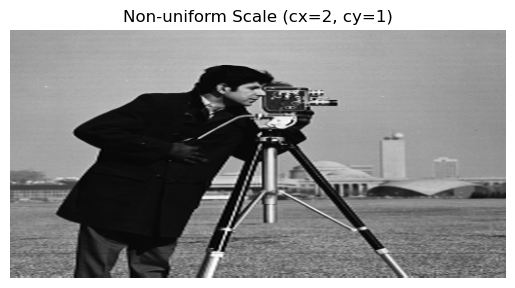

In [8]:
width, height = image.size

non_uniform_image = image.resize(
    (int(width * cx), int(height * cy)),
    Image.Resampling.LANCZOS
)


plt.imshow(non_uniform_image, cmap="gray")
plt.title("Non-uniform Scale (cx=2, cy=1)")
plt.axis("off")
plt.show()

In [9]:
non_uniform_image.save("task1_1_non_uniform.jpg")

print("Original size:", image.size)
print("Non-uniform scaled size:", non_uniform_image.size)

Original size: (256, 256)
Non-uniform scaled size: (512, 256)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (256, 256)
Rotated size: (350, 350)


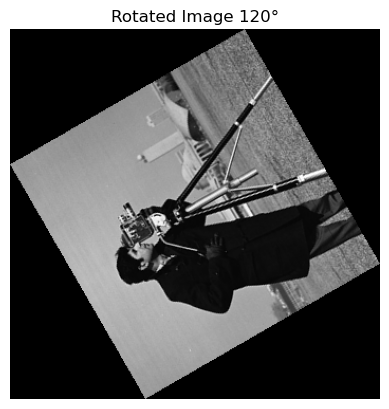

In [10]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_image = image.rotate(
    120,
    expand=True,
    resample=Image.Resampling.BICUBIC
)

rotated_image.save("task1_2_rotated.jpg")

print("Original size:", image.size)
print("Rotated size:", rotated_image.size)


plt.imshow(rotated_image, cmap="gray")
plt.title("Rotated Image 120°")
plt.axis("off")
plt.show()

### 3. Shear

In [11]:
# -- c. Get the image dimensions ────────────────────
width, height = image.size

In [12]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5

# X-axis shear
shear_matrix = (
    1, -shear_factor, 0,
    0, 1, 0
)

new_width = int(width + abs(shear_factor) * height)

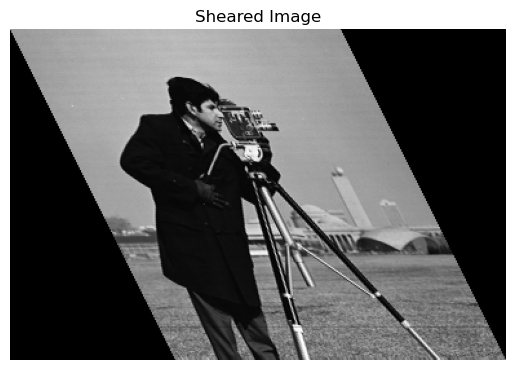

In [13]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
sheared_image = image.transform(
    (new_width, height),
    Image.Transform.AFFINE,
    shear_matrix,
    resample=Image.Resampling.BICUBIC
)


plt.imshow(sheared_image, cmap="gray")
plt.title("Sheared Image")
plt.axis("off")
plt.show()

In [14]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_image.save("task1_3_sheared.jpg")


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

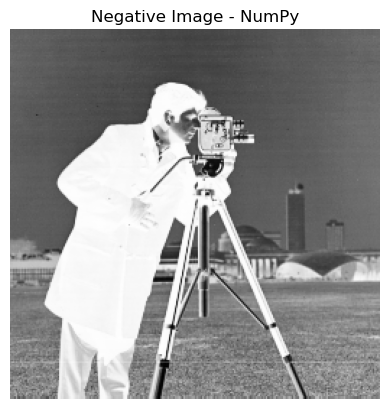

In [15]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
arr = np.array(image)
negative_arr = 255 - arr

negative_image = Image.fromarray(negative_arr.astype(np.uint8))

negative_image.save("negative_numpy.jpg")

plt.imshow(negative_image, cmap="gray")
plt.title("Negative Image - NumPy")
plt.axis("off")
plt.show()



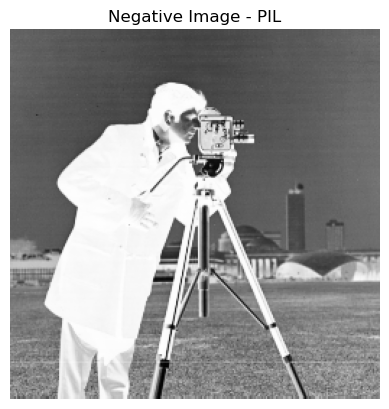

In [16]:
# Method 2: PIL's ImageOps


from PIL import ImageOps

negative_pil = ImageOps.invert(image)

negative_pil.save("negative_pil.jpg")

plt.imshow(negative_pil, cmap="gray")
plt.title("Negative Image - PIL")
plt.axis("off")
plt.show()

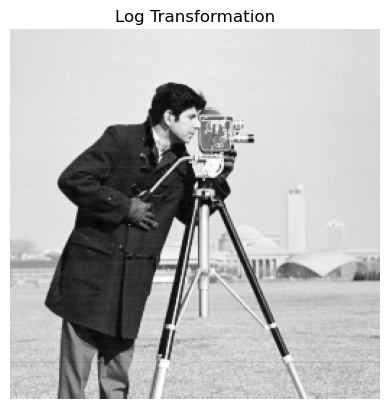

In [17]:
# ── 2. Log transformation ──────────────────────────

arr = np.array(image).astype(np.float32)

c = 255 / np.log(1 + 255)

log_transformed_arr = c * np.log1p(arr)

log_transformed_arr = np.clip(
    log_transformed_arr, 0, 255
).astype(np.uint8)

log_image = Image.fromarray(log_transformed_arr)

log_image.save("log_transformed.jpg")

plt.imshow(log_image, cmap="gray")
plt.title("Log Transformation")
plt.axis("off")
plt.show()

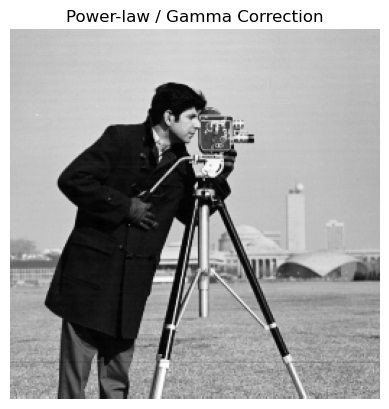

In [18]:

# ── 3. Power-law / Gamma correction ───────────────

arr = np.array(image).astype(np.float32)

gamma = 0.5

gamma_transformed_arr = 255 * (arr / 255) ** gamma
gamma_transformed_arr = np.clip(gamma_transformed_arr, 0, 255).astype(np.uint8)

gamma_image = Image.fromarray(gamma_transformed_arr)

gamma_image.save("gamma_transformed.jpg")

plt.imshow(gamma_image, cmap="gray")
plt.title("Power-law / Gamma Correction")
plt.axis("off")
plt.show()